# Discovery limit for quasi-degenerate two axions vs single massless axion

- **H1:** Two axions with $m_1 \sim m_2 \sim 0$, parametrized by $\Delta m^2 = m_2^2 - m_1^2$
  $$P = 0.5 + 0.5 \cos\!\left(\frac{\Delta m^2\, L_{\mathrm{ES}}}{2E}\right) \times \text{damping}$$
- **H0:** Single massless axion ($P = 1$)

Scans over $\Delta m^2$ and computes $g_{\mathrm{discovery}}(\sqrt{\Delta m^2})$.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os
plt.rcParams.update({'text.usetex':True})
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
%matplotlib widget
%load_ext autoreload
%autoreload 2

from iaxo_params import omega_min, omega_max, setup_plot_style
from conversion_prob import dN_domega
from test_statistic import compute_discovery_limit

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameters

In [ ]:
E_res_keV = 0.1          # Energy resolution [keV]
n_uniform = 100000         # Grid points

# Dm2 scan range1
delta_m2_min = (3e-9)**2      # eV^2 (sqrt = 3e-9 eV)
delta_m2_maxmed = (2e-5)**2  # eV^2 (sqrt = 1e-5 eV)
delta_m2_max = (2e-5)**2  # eV^2 (sqrt = 1e-5 eV)
# 20 points for fast computation, choose 100 for final plot
# n_dm2 =100
n_dm2 = 20
# Dm2 scan range2
n_dm22 = 1


delta_m2_vals = np.append( np.logspace(np.log10(delta_m2_min), np.log10(delta_m2_maxmed), n_dm2),
                            np.logspace(np.log10(delta_m2_maxmed), np.log10(delta_m2_max), n_dm22) )
sqrt_dm2 = np.sqrt(delta_m2_vals)

# Load CAST and IAXO limits/projections
data = np.loadtxt('input_data/CAST_IAXO_exclusion.dat')
sqrt_dm2_data = data[:, 0]  # sqrt(Delta_m21^2) [eV]
g_CAST = data[:, 1]         # g exclusion CAST [GeV^-1]
g_IAXO = data[:, 2]         # g projection IAXO [GeV^-1]

# Interpolation of CAST exclusion limit (log-log)
from scipy.interpolate import interp1d
g_CAST_interp = interp1d(np.log10(sqrt_dm2_data), np.log10(g_CAST),
                         kind='linear', fill_value='extrapolate')
# Usage: g_CAST_at_m = 10**g_CAST_interp(np.log10(m_values))

## Compute discovery limit

In [14]:
print("Quasi-degenerate two axions vs single massless axion")
print(f"sqrt(Dm2) range: [{np.sqrt(delta_m2_min):.1e}, {np.sqrt(delta_m2_max):.1e}] eV")
print(f"E_res = {E_res_keV*1000:.0f} meV, n_points = {n_dm2}")

# H1 factory: given dm2 AND E_res, return spectrum function.
# Analytic damping inside P_conversion handles the fast oscillation smearing
# exactly.  gaussian_filter1d in compute_q0 handles the smooth envelope.
def make_H1(dm2, E_res_keV_val):
    m2_eff = np.sqrt(dm2)
    return lambda E, m=m2_eff, er=E_res_keV_val: dN_domega(E, m1=0, m2=m, E_res_keV=er)

# H0: single massless axion
dN_H0 = lambda E: dN_domega(E, m1=0, m2=0)

g_discovery, q0_over_g4 = compute_discovery_limit(
    delta_m2_vals, lambda dm2: make_H1(dm2, E_res_keV), dN_H0,
    E_res_keV=E_res_keV, n_uniform=n_uniform, verbose=True)
g_discoveryEres10, q0_over_g4Eres10 = compute_discovery_limit(
    delta_m2_vals, lambda dm2: make_H1(dm2, 0.01), dN_H0,
    E_res_keV=0.01, n_uniform=n_uniform, verbose=True)
g_discoveryEres200, q0_over_g4Eres200 = compute_discovery_limit(
    delta_m2_vals, lambda dm2: make_H1(dm2, 0.2), dN_H0,
    E_res_keV=0.2, n_uniform=n_uniform, verbose=True)

Quasi-degenerate two axions vs single massless axion
sqrt(Dm2) range: [3.0e-09, 2.0e-05] eV
E_res = 100 meV, n_points = 100
  [1/101] mass = 9.00e-18
  [11/101] mass = 5.33e-17
  [21/101] mass = 3.16e-16
  [31/101] mass = 1.87e-15
  [41/101] mass = 1.11e-14
  [51/101] mass = 6.56e-14
  [61/101] mass = 3.88e-13
  [71/101] mass = 2.30e-12
  [81/101] mass = 1.36e-11
  [91/101] mass = 8.07e-11
  [101/101] mass = 4.00e-10
  [1/101] mass = 9.00e-18
  [11/101] mass = 5.33e-17
  [21/101] mass = 3.16e-16
  [31/101] mass = 1.87e-15
  [41/101] mass = 1.11e-14
  [51/101] mass = 6.56e-14
  [61/101] mass = 3.88e-13
  [71/101] mass = 2.30e-12
  [81/101] mass = 1.36e-11
  [91/101] mass = 8.07e-11
  [101/101] mass = 4.00e-10
  [1/101] mass = 9.00e-18
  [11/101] mass = 5.33e-17
  [21/101] mass = 3.16e-16
  [31/101] mass = 1.87e-15
  [41/101] mass = 1.11e-14
  [51/101] mass = 6.56e-14
  [61/101] mass = 3.88e-13
  [71/101] mass = 2.30e-12
  [81/101] mass = 1.36e-11
  [91/101] mass = 8.07e-11
  [101/101] m

In [32]:
# ── SAVE results to file ──
import os
_results_dir = os.path.join(os.getcwd(), 'results')
os.makedirs(_results_dir, exist_ok=True)

E_res_runs = {
    10:  (g_discoveryEres10,  q0_over_g4Eres10),
    100: (g_discovery,        q0_over_g4),
    200: (g_discoveryEres200, q0_over_g4Eres200),
}

for E_res_eV, (g_disc, q0) in E_res_runs.items():
    fname = os.path.join(_results_dir, f'Quasi_Eres{E_res_eV}eV.txt')
    data_out = np.column_stack([sqrt_dm2, g_disc, q0])
    header = ('Counting axions with IAXO \\cite{} by B. Grinstein, C. Miro and P. Quilez\n'
              'Quasi-degenerate g_discovery of 2 axions as a function of sqrt_dm2\n'
              'sqrt_dm2[eV]    g_disc[GeV^-1]    q0_over_g4[GeV^-4]')
    np.savetxt(fname, data_out, header=header, fmt='%.6e')
    print(f"Saved:  {fname}")

Saved:  /home/pabloql/Cloud/Dropbox/Two axions at ALPSII and IAXO/Pablo/results/Quasi_Eres10eV.txt
Saved:  /home/pabloql/Cloud/Dropbox/Two axions at ALPSII and IAXO/Pablo/results/Quasi_Eres100eV.txt
Saved:  /home/pabloql/Cloud/Dropbox/Two axions at ALPSII and IAXO/Pablo/results/Quasi_Eres200eV.txt


In [7]:
# ── LOAD results from file (run this INSTEAD of the computation cell above) ──
import os
_results_dir = os.path.join(os.getcwd(), 'results_data')

E_res_eV_list = [10, 100, 200]   # must match what was saved

loaded = {}
for E_res_eV in E_res_eV_list:
    fname = os.path.join(_results_dir, f'Quasi_Eres{E_res_eV}eV.txt')
    data = np.loadtxt(fname)   # columns: sqrt_dm2, g_disc, q0_over_g4
    loaded[E_res_eV] = {'sqrt_dm2': data[:, 0], 'g_disc': data[:, 1], 'q0': data[:, 2]}
    print(f'Loaded: {fname}')

sqrt_dm2            = loaded[100]['sqrt_dm2']
delta_m2_vals       = sqrt_dm2**2
g_discovery         = loaded[100]['g_disc']
q0_over_g4          = loaded[100]['q0']
g_discoveryEres10   = loaded[10]['g_disc']
q0_over_g4Eres10    = loaded[10]['q0']
g_discoveryEres200  = loaded[200]['g_disc']
q0_over_g4Eres200   = loaded[200]['q0']

print(f'\n{len(E_res_eV_list)} resolutions, {len(sqrt_dm2)} mass points each')


Loaded: /home/pabloql/Cloud/ownCloud/MineOwnCountingAxionIAXO/counting-axions-iaxo/unbinned/results_data/Quasi_Eres10eV.txt
Loaded: /home/pabloql/Cloud/ownCloud/MineOwnCountingAxionIAXO/counting-axions-iaxo/unbinned/results_data/Quasi_Eres100eV.txt
Loaded: /home/pabloql/Cloud/ownCloud/MineOwnCountingAxionIAXO/counting-axions-iaxo/unbinned/results_data/Quasi_Eres200eV.txt

3 resolutions, 101 mass points each


## Plot

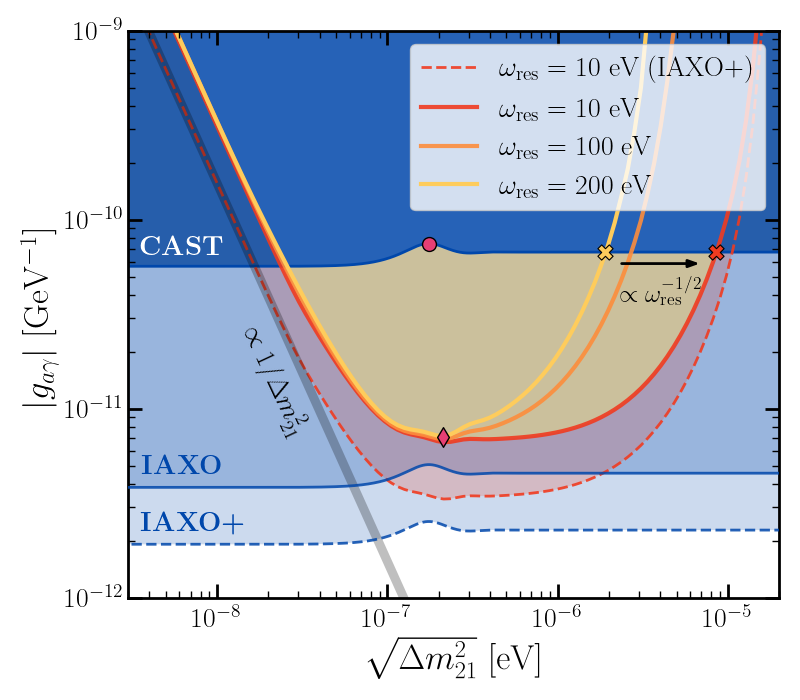

In [15]:
from palettable.colorbrewer.sequential import YlOrRd_3,YlOrRd_5,Greens_5,OrRd_9,PuRd_8, Blues_9
from palettable.cartocolors.sequential import  TealGrn_6


colorsBounds = ["#0047AB", '#0047AB', '#0047AB']
colors = YlOrRd_5.mpl_colors[1:]
import matplotlib.patheffects as pe
def line_background(lw,col):
    return [pe.Stroke(linewidth=lw, foreground=col), pe.Normal()]

%matplotlib widget
setup_plot_style()
fig, ax = plt.subplots(figsize=(8, 7))

# CAST exclusion
ax.loglog(sqrt_dm2_data, g_CAST, color=colorsBounds[2], lw=2, zorder=1)
ax.fill_between(sqrt_dm2_data, g_CAST, 1e-8, facecolor=colorsBounds[2],  zorder=0.5, alpha=0.85)
ax.text(3.5e-9, 6.5e-11, r'{\bf CAST}', fontsize=20, color='w', zorder=1000 )

# IAXO projection
ax.fill_between(sqrt_dm2_data, g_IAXO, g_CAST, facecolor=colorsBounds[1],  zorder=0.05, alpha=0.4)
ax.loglog(sqrt_dm2_data, g_IAXO,colorsBounds[1] , lw=2, ls='-', zorder=8, alpha=0.85)
ax.text(3.56e-9, 4.5e-12, r'{\bf IAXO}', fontsize=20, color=colorsBounds[1], zorder=1000
# ,path_effects=line_background(1.5,'#2E8B57')
)
# IAXO+ projection
ax.fill_between(sqrt_dm2_data, 0.5*g_IAXO, g_IAXO, facecolor=colorsBounds[0],  zorder=0.05, alpha=0.2)
ax.loglog(sqrt_dm2_data, 0.5*g_IAXO,color=colorsBounds[0] , lw=2, ls='--', zorder=8, alpha=0.85)
ax.text(3.5e-9, 4.5e-12/2, r'{\bf IAXO+}', fontsize=20, color=colorsBounds[0], zorder=1000)

#IAXO+ discovery disengalgement
ax.loglog(sqrt_dm2, g_discoveryEres10/2, color=colors[2], lw=2,ls='--',
          label=r'${\omega}_{\rm res} = 10$ eV (IAXO+)', zorder=2,alpha=0.9)

ax.fill_between(sqrt_dm2, g_discoveryEres10/2,g_discoveryEres10,
                facecolor=colors[2], alpha=0.2, zorder=0.1)

# #Res 0.01 keV
# ax.loglog(sqrt_dm2, g_discoveryEres1, color=colors[2], lw=3,
#           label=r'${\omega}_{\rm res} = 1$ eV', zorder=2,alpha=0.9)

#Res 0.01 keV
ax.loglog(sqrt_dm2, g_discoveryEres10, color=colors[2], lw=3,
          label=r'${\omega}_{\rm res} = 10$ eV', zorder=2,alpha=0.9)
#Res 0.1 keV
ax.loglog(sqrt_dm2, g_discovery, color=colors[1], lw=3,
          label=
          r'${\omega}_{\rm res} = 100$ eV', zorder=2,alpha=0.9)
#Res 0.2 keV
ax.loglog(sqrt_dm2[:-6], g_discoveryEres200[:-6], color=colors[0], lw=3,
          label=r'${\omega}_{\rm res} = 200$ eV', zorder=2,alpha=1)

#Fill Yellow disengangling 2 axions region
ax.fill_between(sqrt_dm2, g_discoveryEres10,10**g_CAST_interp(np.log10(sqrt_dm2)),
                facecolor=colors[0], alpha=0.5, zorder=0.1)

# Reference line g ~ 1/Dm2^2
m_ref_start = sqrt_dm2[0]
g_ref_start = g_discoveryEres10[0]
m_ref_end = sqrt_dm2[-1]
g_ref_end = g_ref_start * (m_ref_start / m_ref_end)**2
ax.loglog([m_ref_start, m_ref_end], [g_ref_start/2, g_ref_end/2], 'k-',
          lw=6.5, alpha=0.25)
ax.text(1.3e-8, 1.3e-11/1.8,  r'$ \propto 1/\Delta m_{21}^{2}$', fontsize=20, color="k", zorder=1000,rotation=-65
        # ,path_effects=line_background(1.5,'#2E8B57')
)
ax.set_xlabel(r'$\sqrt{\Delta m_{21}^2}$ [eV]', fontsize=25,path_effects=line_background(3.5, 'w'))
ax.set_ylabel(r'$|g_{a\gamma}|$ [GeV$^{-1}$]', fontsize=25)
# ax.set_title(r'Two-Axion Discovery Limit (IAXO, quasi-degenerate)', fontsize=16)

ax.set_ylim([1e-12, 1e-9])
# ax.set_xlim([sqrt_dm2[0], sqrt_dm2[-1]])

# #UNCOMENT THIS
ax.set_xlim([3e-9, 2e-5])
ax.tick_params(which='major', direction='in', length=10, width=2, top=True, right=True,zorder=100)
ax.tick_params(which='minor', direction='in', length=5, width=1, top=True, right=True,zorder=100)

#Markers intersting point
# Relevant points
from palettable.cartocolors.qualitative import Bold_10
colorsCarlos = Bold_10.mpl_colors
x1_val = 1.75e-7# [eV]
y1_val = 7.47e-11
ax.scatter(x1_val,y1_val,color=colorsCarlos[4],s=100,zorder=50,marker='o',edgecolor='black')
# ,           label=r'$\sqrt{\Delta m_{21}^2}=1.75\times 10^{-7}\ \mathrm{eV}$')

x3_val = 2.12e-7 # [eV]
y3_val = 7.04e-12
ax.scatter(x3_val,y3_val,color=colorsCarlos[4],s=100,zorder=50,marker='d',edgecolor='black')
        #    label=r'$\sqrt{\Delta m_{21}^2}=2.12\times 10^{-7}\ \mathrm{eV}$')

# --- CAST crossing markers & arrow for omega_res^{-1/2} scaling ---
g_CAST_level = 6.7311e-11  # CAST bound [GeV^-1]
# Crossing points from the numerical scan (cell ycell-17)
cross_200 = 1.91e-06  # sqrt(Dm2)_max for 200 eV
cross_100 = 2.7111e-06  # sqrt(Dm2)_max for 100 eV
cross_10  = 8.538e-6  # sqrt(Dm2)_max for 10 eV

# Markers at CAST crossings (color-matched to curves)
ax.scatter(cross_200, g_CAST_level, color=colors[0], s=120, zorder=55,
           marker='X', edgecolor='k', linewidths=0.8)
# ax.scatter(cross_100, g_CAST_level, color=colors[1], s=120, zorder=55,
        #    marker='*', edgecolor='k', linewidths=0.8)
ax.scatter(cross_10,  g_CAST_level, color=colors[2], s=120, zorder=55,
           marker='X', edgecolor='k', linewidths=0.8)

# Arrow from 200 eV crossing to 10 eV crossing along CAST line
ax.annotate('', xy=(cross_10/1.2, g_CAST_level/1.15),
            xytext=(cross_200*1.2, g_CAST_level/1.15),
            arrowprops=dict(arrowstyle='-|>,head_length=0.45,head_width=0.16',
                            color='k', lw=2),
            zorder=60)
ax.text(np.sqrt(cross_200 * cross_10), g_CAST_level/1.95,
        r'$\propto \omega_{\rm res}^{-1/2}$',
        fontsize=18, ha='center', va='bottom', color='k', zorder=60,
        # path_effects=line_background(3, 'w')
        )

leg = ax.legend(fontsize=20, loc='upper right')
leg.set_zorder(20)
ax.set_zorder(100)
ax.set_axisbelow(False)
# ax.grid(True, linestyle='--', alpha=0.3)
ax.tick_params(zorder=1000)
for line in ax.xaxis.get_ticklines():
    line.set_zorder(1000)
for line in ax.yaxis.get_ticklines():
    line.set_zorder(1000)
x4_val = x3_val*0.7 # [eV]
y4_val = y3_val*1.07


ax.tick_params(axis='both', labelsize=20)
ax.tick_params(axis='x', pad=7)  # increase from default ~3.5
ax.tick_params(axis='y', pad=3)  


plt.tight_layout()
plt.show()

# #Save plot
# draft = True  # Set to True to also save to Overleaf folder

# plot_dir = os.path.join(os.getcwd(), 'Plots')
# os.makedirs(plot_dir, exist_ok=True)
# plot_path = os.path.join(plot_dir, 'discovery_limit_Quasi.png')
# fig.savefig(plot_path, dpi=150, bbox_inches='tight')
# print(f"Plot saved as '{plot_path}'")

# if draft:
#     overleaf_dir = '/home/pabloql/Cloud/Dropbox/Aplicaciones/Overleaf/Counting axions with helioscopes/plots'
#     overleaf_path = os.path.join(overleaf_dir, 'discovery_limit_Quasi.pdf')
#     fig.savefig(overleaf_path, dpi=300, bbox_inches='tight')
#     print(f"Plot also saved to Overleaf: '{overleaf_path}'")